#  Pipeline NLP Arabe — Code de la Route Marocain

** Devoir 1 — Traitement Automatique du Langage Arabe

---

##  Contexte du Projet

Ce notebook implémente un **pipeline NLP complet** pour transformer automatiquement un fichier PDF juridique arabe (Code de la Route Marocain) en un fichier CSV structuré exploitable.

###  Objectif Principal
Passer d'un **bloc de texte arabe brut** → à des **lignes CSV** où chaque colonne représente une entité juridique précise.

###  Problématique du Traitement Arabe
Le traitement du texte arabe pose des défis spécifiques :
- **RTL (Right-to-Left)** : Le texte arabe s'écrit de droite à gauche, ce qui peut perturber les parsers
- **Tashkeel (تشكيل)** : Les voyelles courtes (harakat) créent du bruit lexical
- **Hamza (همزة)** : Plusieurs formes d'écriture (أ، إ، آ، ء) pour le même son
- **Ta Marbuta (ة)** : Souvent confondue avec Ha (ه) en fin de mot
- **Tatweel (ـ)** : Caractère d'élongation décoratif à supprimer
- **Absence de majuscules** : Pas de distinction typographique pour les noms propres



##  Schéma du Pipeline

```
┌─────────────┐    ┌──────────────┐    ┌─────────────────┐
│  PDF Arabe  │───▶│  Nettoyage   │───▶│  Segmentation   │
│  (entrée)   │    │  PyArabic    │    │  par Articles   │
└─────────────┘    └──────────────┘    └────────┬────────┘
                                                │
                         ┌──────────────────────┘
                         ▼
              ┌─────────────────────┐    ┌──────────────────┐
              │  Extraction NER     │───▶│  Classification  │
              │  (Regex + ML)       │    │  (Rules + BERT)  │
              └─────────────────────┘    └────────┬─────────┘
                                                  │
                                     ┌────────────┘
                                     ▼
                          ┌──────────────────────┐
                          │  Clustering KMeans   │
                          │  + Export CSV Final  │
                          └──────────────────────┘
```

---


---
#  SECTION 2 — Installation des Librairies

Avant tout, nous installons l'ensemble des librairies nécessaires au pipeline. Chaque librairie joue un rôle précis dans la chaîne de traitement NLP.



In [1]:


# --- Manipulation de données ---
# pandas : Création et manipulation de DataFrames (notre sortie CSV finale)
%pip install pandas --quiet

# --- Extraction PDF ---
# pdfplumber : Lecture précise du texte dans les PDFs (gère les colonnes)
%pip install pdfplumber --quiet

# pymupdf (fitz) : Alternative rapide pour l'extraction PDF, utile pour l'OCR
%pip install pymupdf --quiet

# --- NLP Arabe ---
# pyarabic : Librairie spécialisée pour la normalisation du texte arabe
#            (suppression tashkeel, normalisation hamza, ta marbuta...)
%pip install pyarabic --quiet

# --- Expressions Régulières ---
# regex : Version étendue du module 're', supporte les blocs Unicode arabes
%pip install regex --quiet

# --- Machine Learning ---
# scikit-learn : TF-IDF, LogisticRegression, KMeans pour la classification
%pip install scikit-learn --quiet

# --- Modèles de Langage Profonds ---
# transformers : HuggingFace, pour AraBERT et autres modèles pré-entraînés
%pip install transformers --quiet

# torch : Backend PyTorch requis par les transformers
%pip install torch --quiet

# sentence-transformers : Génération rapide d'embeddings de phrases
%pip install sentence-transformers --quiet

# --- Visualisations ---
# matplotlib : Graphiques (histogrammes, distributions)
%pip install matplotlib --quiet

# wordcloud : Nuage de mots (supporte l'arabe avec une police adaptée)
%pip install wordcloud --quiet

# arabic-reshaper + python-bidi : Affichage correct de l'arabe dans matplotlib
%pip install arabic-reshaper python-bidi --quiet

print("✅ Toutes les librairies sont installées avec succès !")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 16.2 MB/s eta 0:00:00
✅ Toutes les librairies sont installées avec succès !


---
#  SECTION 3 — Imports Python

Nous importons ici tous les modules nécessaires et configurons l'environnement de travail.

In [2]:


# ---- Librairies Standard ----
import re                          # Expressions régulières de base
import regex                       # Regex étendu avec support Unicode arabe
import os                          # Gestion des fichiers/répertoires
import json                        # Sérialisation JSON (pour debug)
from collections import Counter    # Comptage de fréquences

# ---- Manipulation de Données ----
import pandas as pd                # DataFrames → export CSV
import numpy as np                 # Calculs numériques (clustering)

# ---- Extraction PDF ----
import pdfplumber                  # Extraction texte PDF avec layout
try:
    import fitz                    # PyMuPDF — alternative extraction PDF
    PYMUPDF_AVAILABLE = True
except ImportError:
    PYMUPDF_AVAILABLE = False
    print("⚠️  PyMuPDF non disponible, utilisation de pdfplumber uniquement")

# ---- NLP Arabe ----
import pyarabic.araby as araby     # Normalisation arabe (hamza, tashkeel...)

# ---- Machine Learning (scikit-learn) ----
from sklearn.feature_extraction.text import TfidfVectorizer  # Vectorisation TF-IDF
from sklearn.linear_model import LogisticRegression           # Classifieur ML
from sklearn.cluster import KMeans                            # Clustering sémantique
from sklearn.preprocessing import LabelEncoder               # Encodage des labels
from sklearn.metrics.pairwise import cosine_similarity        # Similarité cosinus
from sklearn.pipeline import Pipeline                         # Pipeline ML

# ---- Visualisations ----
import matplotlib.pyplot as plt    # Graphiques
import matplotlib                  # Configuration matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)  # Taille par défaut des figures

try:
    from wordcloud import WordCloud   # Nuage de mots
    import arabic_reshaper            # Reshape arabe pour matplotlib
    from bidi.algorithm import get_display  # Affichage RTL
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("⚠️  WordCloud non disponible")

# ---- Transformers HuggingFace (AraBERT) ----
try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    TRANSFORMERS_AVAILABLE = True
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("⚠️  Transformers/Torch non disponibles — section AraBERT désactivée")

# ---- Configuration Générale ----
import warnings
warnings.filterwarnings('ignore')  # Masquer les warnings non critiques
pd.set_option('display.max_colwidth', 80)   # Largeur colonne DataFrame
pd.set_option('display.max_columns', None)  # Afficher toutes les colonnes

print("✅ Imports réussis !")
print(f"   PyMuPDF disponible : {PYMUPDF_AVAILABLE}")
print(f"   WordCloud disponible : {WORDCLOUD_AVAILABLE}")
print(f"   Transformers disponible : {TRANSFORMERS_AVAILABLE}")

✅ Imports réussis !
   PyMuPDF disponible : True
   WordCloud disponible : True
   Transformers disponible : True


---
#  SECTION 4 — Extraction du Texte PDF


In [3]:
from google.colab import files

uploaded = files.upload()

Saving MA52_05.pdf to MA52_05.pdf


In [4]:


def extract_text_from_pdf(pdf_path: str, method: str = 'pdfplumber') -> str:

    full_text = ""
    page_count = 0

    if method == 'pdfplumber':
        # --- Méthode 1 : pdfplumber ---
        # Avantage : préserve mieux la mise en page, gère les colonnes
        with pdfplumber.open(pdf_path) as pdf:
            page_count = len(pdf.pages)
            print(f"📖 Nombre de pages détectées : {page_count}")

            for i, page in enumerate(pdf.pages):
                # Extraire le texte de chaque page
                page_text = page.extract_text()

                if page_text:  # Ignorer les pages vides
                    full_text += page_text + "\n"

    elif method == 'fitz' and PYMUPDF_AVAILABLE:
        # --- Méthode 2 : PyMuPDF (fitz) ---
        # Avantage : plus rapide, meilleure gestion des polices arabes
        doc = fitz.open(pdf_path)
        page_count = len(doc)
        print(f"📖 Nombre de pages détectées : {page_count}")

        for page in doc:
            # flags=4 : préserve les espaces, utile pour l'arabe
            page_text = page.get_text("text", flags=4)
            if page_text:
                full_text += page_text + "\n"
        doc.close()

    print(f"📝 Caractères extraits : {len(full_text):,}")
    print(f"📏 Lignes extraites   : {full_text.count(chr(10)):,}")
    return full_text



PDF_PATH = "MA52_05.pdf"

# Vérification de l'existence du fichier
if not os.path.exists(PDF_PATH):
    print(f"⚠️  Fichier '{PDF_PATH}' non trouvé.")
    print("   → Chargement d'un texte de démonstration arabe...")

    # Texte de démonstration basé sur des articles types du Code de la Route marocain
    raw_text = """
المادة 1
يقصد في مفهوم هذا القانون بالمصطلحات التالية: الطريق: كل طريق أو شارع أو ممر مخصص للسير العام للمركبات والمشاة.

المادة 52
يجب على قائد كل مركبة أن يتحكم في سرعة مركبته ويكيفها حسب ظروف السير والطريق والأحوال الجوية. لا يجوز تجاوز السرعة القصوى المحددة بـ 120 كيلومترا في الساعة على الطرق السيارة. يعاقب على مخالفة هذه المادة بغرامة مالية قدرها 700 درهم وخصم 4 نقط من رصيد النقط.

المادة 53
يحظر على قائد أي مركبة: استعمال الهاتف المحمول أثناء القيادة إلا بواسطة جهاز يتيح استخدامه دون استعمال اليدين. يعاقب على مخالفة هذه المادة بغرامة مالية قدرها 400 درهم وخصم 2 نقطة.

المادة 54
يجب على قائد السيارة ومرافقيه المتنقلين في المقاعد الأمامية والخلفية ارتداء حزام الأمان. يعاقب على مخالفة هذه المادة بغرامة قدرها 400 درهم وخصم 2 نقطة من رصيد النقط.

المادة 84
يمنع الوقوف بصفة مزدوجة أو بطريقة تعيق السير. يعاقب على مخالفة التوقف والوقوف بغرامة مالية قدرها 300 درهم.

المادة 87
يمنع قيادة مركبة في حالة سكر أو تحت تأثير المخدرات أو المؤثرات العقلية. يعاقب على مخالفة هذه المادة بغرامة مالية تتراوح بين 5000 درهم و10000 درهم وسحب رخصة القيادة لمدة سنة إلى 3 سنوات وخصم 8 نقط من رصيد النقط.

المادة 101
يجب على قائد الشاحنة أو الحافلة احترام مسافة الأمان مع المركبات الأخرى. يعاقب على مخالفة هذه المادة بغرامة مالية قدرها 600 درهم وخصم 3 نقط من رصيد النقط.

المادة 108
يجب على قائد الدراجة النارية ارتداء خوذة الحماية. يعاقب على عدم ارتداء الخوذة بغرامة مالية قدرها 300 درهم وخصم 2 نقطة.

المادة 115
يحظر تجاوز الإشارات الضوئية الحمراء. يعاقب على مخالفة هذه المادة بغرامة مالية قدرها 700 درهم وخصم 4 نقط من رصيد النقط وإيقاف الرخصة لمدة شهر.

المادة 130
يجب على قائد مركبة نقل البضائع التحقق من أن الحمولة لا تتجاوز الحد الأقصى المرخص به. يعاقب على التجاوز بغرامة مالية قدرها 1300 درهم.

المادة 184
يُسحب قانونًا رصيد النقط بالكامل عند ارتكاب المخالفات الجسيمة كالقتل الخطأ في حوادث السير. يوقف قائد المركبة عن الحق في القيادة لمدة سنتين.
    """
    print("\n✅ Texte de démonstration chargé (10 articles types)")
else:
    # Chargement du PDF réel
    raw_text = extract_text_from_pdf(PDF_PATH, method='pdfplumber')

# Affichage d'un aperçu du texte brut
print("\n" + "="*60)
print("📃 APERÇU DU TEXTE BRUT (500 premiers caractères) :")
print("="*60)
print(raw_text[:500])

📖 Nombre de pages détectées : 126
📝 Caractères extraits : 221,996
📏 Lignes extraites   : 3,822

📃 APERÇU DU TEXTE BRUT (500 premiers caractères) :
قلعتملا 52.05 مقر نوناقلا
، قرطلا ىلع ريسلا ةنودمب
ه ميمتتو هرييغت عقو امك
خ يراتب ةدطوم ةغيص
2024 ويلوي10
ليهست لجأ نم ةخسنلا هذه دادعإ مت
صوصنلاب لاإ جتحي لاو ،صنلا ةيئورقم
ةيمسرلا ةديرجلاب ةروشنلما اهتغيص يف
ةموكحلل ةماعلا ةناملأا
52.05 مقر نوناقلا
1.10.07 مقر فيرشلا ريهظلا هذيفنتب رداصلا قرطلا ىلع ريسلا ةنودمب قلعتلما
،)2010 رياربف 11( 1431 رفص نم 26 خيراتب
هميمتتو هرييغت عقو امك
)2168 : ص ،)2010 سرام 25(1431 رخلآا عيبر 8 خيراتب 5824 ددع ر.ج(
لولأا باتكلا
ةيمومعلا قيرطلا ىلع ريسلا طورش
لولأا


---
# 🧹 SECTION 5 — Normalisation du Texte Arabe

## Pourquoi Normaliser le Texte Arabe ?

Sans normalisation, le même mot peut apparaître sous **plusieurs formes différentes**, ce qui fausse la recherche et le comptage :

| Problème | Exemple | Solution |
|---|---|---|
| **Tashkeel** | مَادَّة vs مادة | Supprimer les voyelles |
| **Hamza** | أرض، إرشاد، آمن → ارض، ارشاد، امن | Normaliser vers `ا` |
| **Ta Marbuta** | سيارة vs سياره | Uniformiser vers `ه` |
| **Alef Maksoura** | يعطى vs يعطي | Uniformiser vers `ي` |
| **Tatweel** | مـادة → مادة | Supprimer `ـ` |
| **Espaces multiples** | `مادة  1` → `مادة 1` | Normaliser espaces |

In [5]:
# ==============================================================
# SECTION 5 : NORMALISATION DU TEXTE ARABE
# ==============================================================

def normalize_arabic(text: str) -> str:
    """
    Normalise le texte arabe pour le traitement NLP.

    Opérations effectuées (dans l'ordre) :
      1. Suppression du Tashkeel (voyelles courtes)
      2. Normalisation de la Hamza (toutes les formes → ا)
      3. Suppression du Tatweel (ـ)
      4. Normalisation Ta Marbuta (ة → ه)
      5. Normalisation Alef Maksoura (ى → ي)
      6. Nettoyage des espaces multiples
      7. Suppression des lignes vides superflues

    Args:
        text : Texte arabe brut
    Returns:
        Texte normalisé
    """
    # Étape 1 : Supprimer le Tashkeel (شَكل → شكل)
    # PyArabic fournit strip_tashkeel() pour supprimer toutes les voyelles
    text = araby.strip_tashkeel(text)

    # Étape 2 : Supprimer le Shadda (الشدة) et les autres diacritiques
    text = araby.strip_shadda(text)

    # Étape 3 : Normaliser la Hamza
    # أ، إ، آ → ا  (uniformiser toutes les formes d'Alef-Hamza)
    text = araby.normalize_hamza(text)

    # Étape 4 : Supprimer le Tatweel (ـ)
    # Ce caractère est purement décoratif et crée du bruit
    text = araby.strip_tatweel(text)

    # Étape 5 : Normaliser Ta Marbuta (ة → ه)
    # Uniformise les fins de mots féminins
    text = text.replace('ة', 'ه')

    # Étape 6 : Normaliser Alef Maksoura (ى → ي)
    # Évite la confusion entre les deux formes du Ya
    text = text.replace('ى', 'ي')

    # Étape 7 : Supprimer les caractères non-arabes et non-numériques superflus
    # On garde : lettres arabes, chiffres (arabes et latins), espaces, points, virgules
    text = re.sub(r'[\u200f\u200e\u200d\u200c\u200b]', '', text)  # Marques BiDi
    text = re.sub(r'[\u0640]', '', text)  # Tatweel résiduel

    # Étape 8 : Normaliser les espaces multiples
    text = re.sub(r'[ \t]+', ' ', text)

    # Étape 9 : Supprimer les lignes vides consécutives
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()



# Exemple de texte avec tous les problèmes typiques
sample_raw = "المَادَّةُ الأَوْلَى : يَجِبُ عَلَى قَائِدِ السَّيَّارَةِ ارْتِدَاءُ حِزَامِ الأَمَانِ"

print("🔴 TEXTE AVANT NORMALISATION :")
print(f"   {sample_raw}")
print(f"   Longueur : {len(sample_raw)} caractères")

sample_clean = normalize_arabic(sample_raw)
print("\n🟢 TEXTE APRÈS NORMALISATION :")
print(f"   {sample_clean}")
print(f"   Longueur : {len(sample_clean)} caractères")
print(f"   Réduction : {len(sample_raw) - len(sample_clean)} caractères supprimés")

# Normalisation du texte complet
print("\n" + "="*60)
print("🔄 Normalisation du texte complet...")
cleaned_text = normalize_arabic(raw_text)
print(f"✅ Texte normalisé : {len(cleaned_text):,} caractères")
print("\n📃 Aperçu du texte normalisé (400 premiers caractères) :")
print(cleaned_text[:400])

🔴 TEXTE AVANT NORMALISATION :
   المَادَّةُ الأَوْلَى : يَجِبُ عَلَى قَائِدِ السَّيَّارَةِ ارْتِدَاءُ حِزَامِ الأَمَانِ
   Longueur : 86 caractères

🟢 TEXTE APRÈS NORMALISATION :
   الماده الءولي : يجب علي قاءد السياره ارتداء حزام الءمان
   Longueur : 55 caractères
   Réduction : 31 caractères supprimés

🔄 Normalisation du texte complet...
✅ Texte normalisé : 222,140 caractères

📃 Aperçu du texte normalisé (400 premiers caractères) :
قلعتملا 52.05 مقر نوناقلا
، قرطلا يلع ريسلا هنودمب
ه ميمتتو هرييغت عقو امك
خ يراتب هدطوم هغيص
2024 ويلوي10
ليهست لجء نم هخسنلا هذه دادعء مت
صوصنلاب لاء جتحي لاو ،صنلا هيءورقم
هيمسرلا هديرجلاب هروشنلما اهتغيص يف
هموكحلل هماعلا هناملءا
52.05 مقر نوناقلا
1.10.07 مقر فيرشلا ريهظلا هذيفنتب رداصلا قرطلا يلع ريسلا هنودمب قلعتلما
،)2010 رياربف 11( 1431 رفص نم 26 خيراتب
هميمتتو هرييغت عقو امك
)2168 : ص ،)2


---
# ✂️ SECTION 6 — Segmentation des Articles

## Segmentation Juridique par Articles

Le Code de la Route est organisé en **articles** (مادة). Chaque article commence par le mot **"المادة"** suivi d'un numéro.

**Structure typique d'un article :**
```
المادة [NUMÉRO]
[Texte de l'article : définition, obligation, sanction...]
```

**Stratégie de segmentation** : Utiliser une **Regex de split** sur le pattern `المادة \d+` pour découper le texte en segments individuels.

In [6]:


def split_articles(text: str) -> list[dict]:

    articles = []

    # Pattern de détection d'un article
    # Gère : المادة 52 / الماده 52 / المادة: 52
    ARTICLE_PATTERN = r'(الماد[هة]\s*:?\s*\d+)'

    # Découper le texte en segments via re.split
    # re.split avec un groupe capturant conserve le délimiteur dans la liste
    parts = re.split(ARTICLE_PATTERN, text)

    # Reconstruire les articles : [header, content, header, content, ...]
    i = 0
    while i < len(parts):
        part = parts[i].strip()

        # Vérifier si ce segment est un en-tête d'article
        if re.match(ARTICLE_PATTERN, part):
            # Extraire le numéro d'article
            num_match = re.search(r'(\d+)', part)
            article_num = num_match.group(1) if num_match else "?"

            # Le contenu est dans la partie suivante
            content = ""
            if i + 1 < len(parts):
                content = parts[i + 1].strip()
                i += 2  # Sauter header + content
            else:
                i += 1

            # N'ajouter que si le contenu n'est pas vide
            if content:
                articles.append({
                    'article_num': article_num,
                    'content': f"الماده {article_num}\n{content}",
                    'raw_content': content
                })
        else:
            i += 1

    # Fallback : si aucun article trouvé, traiter chaque ligne comme un article
    if not articles:
        print("⚠️  Pattern المادة non trouvé — découpage par paragraphe")
        paragraphs = [p.strip() for p in text.split('\n\n') if p.strip() and len(p.strip()) > 20]
        for idx, para in enumerate(paragraphs, 1):
            # Chercher un numéro en début de paragraphe
            num_match = re.search(r'الماد[هة]\s*(\d+)', para)
            num = num_match.group(1) if num_match else str(idx)
            articles.append({
                'article_num': num,
                'content': para,
                'raw_content': para
            })

    return articles



articles_list = split_articles(cleaned_text)

print(f"✅ {len(articles_list)} article(s) détecté(s) dans le texte")
print("\n" + "="*60)
print("📄 EXEMPLE D'ARTICLE EXTRAIT :")
print("="*60)

if articles_list:
    sample_article = articles_list[0]
    print(f"  → Numéro  : {sample_article['article_num']}")
    print(f"  → Contenu : {sample_article['content'][:200]}...")

    print("\n📊 Distribution des 5 premiers articles :")
    for art in articles_list[:5]:
        print(f"   Article {art['article_num']:>5} | {len(art['content'])} chars | {art['content'][:60]}...")

⚠️  Pattern المادة non trouvé — découpage par paragraphe
✅ 1 article(s) détecté(s) dans le texte

📄 EXEMPLE D'ARTICLE EXTRAIT :
  → Numéro  : 1
  → Contenu : قلعتملا 52.05 مقر نوناقلا
، قرطلا يلع ريسلا هنودمب
ه ميمتتو هرييغت عقو امك
خ يراتب هدطوم هغيص
2024 ويلوي10
ليهست لجء نم هخسنلا هذه دادعء مت
صوصنلاب لاء جتحي لاو ،صنلا هيءورقم
هيمسرلا هديرجلاب هروشنلما...

📊 Distribution des 5 premiers articles :
   Article     1 | 222140 chars | قلعتملا 52.05 مقر نوناقلا
، قرطلا يلع ريسلا هنودمب
ه ميمتتو ...


---
# 🔍 SECTION 7 — Extraction Rule-Based (NER par Regex)

## NLP Basé sur les Règles (Rule-Based NLP)

Le **langage juridique** est fortement codifié et répétitif : les mêmes formulations apparaissent de manière systématique. C'est pourquoi les **Regex Unicode** sont l'outil privilégié pour l'extraction d'entités dans ce contexte.

### Avantages des Regex pour le Juridique :
- ✅ **Précision** : 100% de recall sur les patterns connus
- ✅ **Interprétabilité** : On comprend exactement ce qui est extrait
- ✅ **Pas de données d'entraînement** nécessaires
- ✅ **Rapide** à implémenter pour un domaine précis

### Patterns identifiés dans le Code de la Route :

| Entité | Pattern Regex | Exemple |
|---|---|---|
| Numéro Article | `الماده\s+(\d+)` | المادة 52 |
| Amende | `(\d+)\s*(درهم\|درهما)` | 700 درهم |
| Points retrait | `خصم\s+(\d+)\s+نقط` | خصم 4 نقط |
| Durée suspension | `(\d+)\s+(سنه\|شهر\|يوم)` | سنة إلى 3 سنوات |
| Type véhicule | Dictionnaire de mots-clés | شاحنه، دراجه |


In [7]:


# -------------------------------------------------------
# 7.1 — Extraction du numéro d'article
# -------------------------------------------------------
def extract_article_id(text: str) -> str:
    """
    Extrait le numéro d'article depuis le texte.
    Pattern : 'المادة' ou 'الماده' suivi d'un ou plusieurs chiffres
    """
    # Gère المادة, الماده, مادة, ماده
    pattern = r'(?:الماد[هة]|ماد[هة])\s*:?\s*(\d+)'
    match = re.search(pattern, text)
    return match.group(1) if match else None


# -------------------------------------------------------
# 7.2 — Extraction des amendes
# -------------------------------------------------------
def extract_amende(text: str) -> list:
    """
    Extrait tous les montants d'amende en dirhams.
    Patterns :
      - 700 درهم
      - 5000 درهما
      - من 1000 إلى 3000 درهم (amende fourchette)
    """
    amendes = []

    # Pattern 1 : Montant fixe
    p1 = r'(\d[\d\s]*)\s*(?:درهم|درهما|دراهم)'
    for m in re.finditer(p1, text):
        val = m.group(1).replace(' ', '').strip()
        try:
            amendes.append(int(val))
        except:
            pass

    # Pattern 2 : Fourchette "من X إلى Y درهم"
    p2 = r'(?:من|بين)\s*(\d+)\s*(?:إلى|و)\s*(\d+)\s*درهم'
    for m in re.finditer(p2, text):
        # Garder la valeur minimale comme amende fixe
        amendes.append(int(m.group(1)))

    # Retourner l'amende la plus basse si plusieurs trouvées
    return min(amendes) if amendes else None


# -------------------------------------------------------
# 7.3 — Extraction des points de retrait
# -------------------------------------------------------
def extract_points(text: str) -> int:
    """
    Extrait le nombre de points retirés.
    Patterns :
      - خصم 4 نقط
      - خصم 4 نقطة
      - 4 نقط من رصيد النقط
    """
    # Pattern principal : خصم X نقط
    p1 = r'خصم\s*(\d+)\s*(?:نقط|نقطه|نقطة)'
    m = re.search(p1, text)
    if m: return int(m.group(1))

    # Pattern alternatif : X نقط من رصيد
    p2 = r'(\d+)\s*(?:نقط|نقطه|نقطة)\s+من\s+رصيد'
    m = re.search(p2, text)
    if m: return int(m.group(1))

    # Pattern court : سحب X نقط
    p3 = r'(?:سحب|فقدان)\s*(\d+)\s*(?:نقط|نقطه|نقطة)'
    m = re.search(p3, text)
    if m: return int(m.group(1))

    return None


# -------------------------------------------------------
# 7.4 — Extraction de la durée de suspension
# -------------------------------------------------------
def extract_duree_suspension(text: str) -> str:
    """
    Extrait la durée de suspension/retrait du permis.
    Patterns :
      - سحب رخصة القيادة لمدة 6 أشهر
      - إيقاف الرخصة لمدة شهر
      - سنة إلى 3 سنوات
    """
    # Pattern 1 : لمدة X (سنة|شهر|يوم)
    p1 = r'لمد[هة]\s*(\d+)\s*(سن[هة]|شهر|يوم|أشهر|سنوات|أيام)'
    m = re.search(p1, text)
    if m: return f"{m.group(1)} {m.group(2)}"

    # Pattern 2 : fourchette "سنة إلى X سنوات"
    p2 = r'(\d+)?\s*(سن[هة]|شهر|يوم)\s+إلى\s+(\d+)\s*(سن[هة]|سنوات|شهر|أشهر)'
    m = re.search(p2, text)
    if m: return f"{m.group(1) or '1'} إلى {m.group(3)} {m.group(4)}"

    # Pattern 3 : لمدة شهر (sans chiffre)
    p3 = r'لمد[هة]\s*(شهر|سنه|يوم)'
    m = re.search(p3, text)
    if m: return m.group(1)

    return None


# -------------------------------------------------------
# 7.5 — Extraction de la catégorie de véhicule
# -------------------------------------------------------
VEHICULE_MAP = {
    'poids_lourd': [
        'شاحنه', 'شاحنة', 'مركبه ثقيله', 'شاحنات', 'نقل البضائع', 'عربه جر',
        'مركبة ثقيلة', 'شاحنة النقل', 'الشاحنات'
    ],
    'vehicule_leger': [
        'سياره', 'سيارة', 'مركبه خفيفه', 'سيارة السياحة', 'سيارات', 'السيارة'
    ],
    'moto': [
        'دراجه', 'دراجة', 'دراجه ناريه', 'دراجة نارية', 'الدراجات النارية'
    ],
    'bus': [
        'حافله', 'حافلة', 'نقل جماعي', 'نقل المسافرين', 'الحافلة'
    ],
    'tous_vehicules': [
        'مركبه', 'مركبة', 'قائد', 'السائق', 'كل مركبه'
    ]
}

def extract_categorie_vehicule(text: str) -> str:
    """
    Détecte la catégorie de véhicule mentionnée dans l'article.
    Ordre de priorité : poids_lourd > moto > bus > véhicule_léger > tous
    """
    text_lower = text.lower()

    # Priorité : du plus spécifique au plus général
    for categorie in ['poids_lourd', 'moto', 'bus', 'vehicule_leger', 'tous_vehicules']:
        keywords = VEHICULE_MAP[categorie]
        for kw in keywords:
            if kw in text_lower:
                return categorie

    return 'non_specifie'


# -------------------------------------------------------
# 7.6 — Extraction des mots-clés d'infraction
# -------------------------------------------------------
KEYWORDS_INFRACTIONS = {
    'vitesse'       : ['سرعه', 'سرعة', 'تجاوز السرعه', 'السرعه القصوى'],
    'stationnement' : ['وقوف', 'توقف', 'ركن', 'انتظار'],
    'depassement'   : ['تجاوز', 'تخطي'],
    'telephone'     : ['هاتف', 'جوال', 'موبايل', 'هاتف المحمول'],
    'ceinture'      : ['حزام', 'حزام الامان', 'حزام السلامه'],
    'feu_rouge'     : ['اشاره', 'إشارة', 'ضوء احمر', 'إشارة الوقوف'],
    'alcool'        : ['سكر', 'كحول', 'خمر', 'مخدرات'],
    'casque'        : ['خوذه', 'خوذة', 'خوذة الحمايه'],
    'distance'      : ['مسافه الامان', 'تباعد', 'مسافه الفاصله'],
    'nuit'          : ['ليل', 'مصابيح', 'اضاءه'],
    'surcharge'     : ['حموله', 'تجاوز الحموله', 'وزن'],
    'autoroute'     : ['طريق سيار', 'طريق سياره', 'الطريق السريع'],
}

def extract_mots_cles(text: str) -> list:
    """
    Extrait les mots-clés d'infraction présents dans le texte.
    Retourne une liste de tags thématiques.
    """
    tags = []
    text_lower = text.lower()

    for tag, keywords in KEYWORDS_INFRACTIONS.items():
        for kw in keywords:
            if kw in text_lower:
                tags.append(tag)
                break  # Un seul tag par catégorie

    return tags if tags else ['autre']


# -------------------------------------------------------
# TEST DES EXTRACTEURS
# -------------------------------------------------------
print("🧪 TEST DES EXTRACTEURS REGEX")
print("="*60)

test_article = "الماده 52 : يعاقب على تجاوز السرعه بغرامه ماليه قدرها 700 درهم وخصم 4 نقط من رصيد النقط وإيقاف الرخصه لمده شهر"

print(f"  Texte test : {test_article}")
print(f"  → article_id      : {extract_article_id(test_article)}")
print(f"  → amende_fixe     : {extract_amende(test_article)} DH")
print(f"  → points_retrait  : {extract_points(test_article)}")
print(f"  → duree_suspension: {extract_duree_suspension(test_article)}")
print(f"  → categorie_veh   : {extract_categorie_vehicule(test_article)}")
print(f"  → mots_cles       : {extract_mots_cles(test_article)}")

🧪 TEST DES EXTRACTEURS REGEX
  Texte test : الماده 52 : يعاقب على تجاوز السرعه بغرامه ماليه قدرها 700 درهم وخصم 4 نقط من رصيد النقط وإيقاف الرخصه لمده شهر
  → article_id      : 52
  → amende_fixe     : 700 DH
  → points_retrait  : 4
  → duree_suspension: شهر
  → categorie_veh   : non_specifie
  → mots_cles       : ['vitesse', 'depassement']


---
# 🏷️ SECTION 8 — Classification des Articles

## 8.1 — Classification par Règles (Rule-Based)

On classe chaque article selon son **type sémantique** :

| Type | Marqueurs Linguistiques Arabes | Description |
|---|---|---|
| **Sanction** | غرامة، عقوبة، خصم، يعاقب | Définit une pénalité |
| **Obligation** | يجب، يلزم، يمنع، يحظر | Impose un comportement |
| **Définition** | يقصد، يراد، يُعرَّف | Définit un terme juridique |

In [8]:
# ==============================================================
# SECTION 8.1 : CLASSIFICATION RULE-BASED
# ==============================================================

# Dictionnaire des marqueurs linguistiques par type
TYPE_MARKERS = {
    'sanction': [
        'غرامه', 'غرامة', 'عقوبه', 'عقوبة', 'خصم', 'يعاقب',
        'يُعاقب', 'جزاء', 'جزائي', 'درهم', 'سجن', 'حبس', 'ايقاف', 'سحب رخصه'
    ],
    'obligation': [
        'يجب', 'يلزم', 'يمنع', 'يحظر', 'لا يجوز', 'ينبغي',
        'ملزم', 'إلزامي', 'وجوب', 'التزام', 'ضرورة'
    ],
    'definition': [
        'يقصد', 'يُقصد', 'يراد', 'يُراد', 'يعني', 'يُعرف',
        'مفهوم', 'تعريف', 'المقصود', 'هو عباره عن'
    ],
    'procedure': [
        'تقديم', 'طلب', 'تسجيل', 'تسليم', 'اجراء', 'إجراء',
        'بطاقه', 'وثيقه', 'شهاده'
    ]
}

def classify_article_rules(text: str) -> str:
    """
    Classifie un article juridique selon ses marqueurs linguistiques.

    Logique : compte les occurrences de marqueurs par catégorie
    et retourne la catégorie avec le plus grand score.

    Args:
        text : Texte de l'article
    Returns:
        Type d'article : 'sanction' | 'obligation' | 'definition' | 'procedure' | 'autre'
    """
    scores = {t: 0 for t in TYPE_MARKERS}
    text_lower = text.lower()

    for type_name, markers in TYPE_MARKERS.items():
        for marker in markers:
            # Compter les occurrences de chaque marqueur
            scores[type_name] += text_lower.count(marker)

    # Retourner le type dominant
    best_type = max(scores, key=scores.get)
    return best_type if scores[best_type] > 0 else 'autre'


# Test de classification
print("🏷️ TEST DE CLASSIFICATION RULE-BASED")
print("="*60)

tests = [
    "يعاقب على مخالفه هذه الماده بغرامه ماليه قدرها 700 درهم",
    "يجب على قائد السياره ارتداء حزام الامان في جميع الاوقات",
    "يقصد بالطريق كل مسار مخصص للسير العام للمركبات والمشاه"
]

for t in tests:
    print(f"  → [{classify_article_rules(t):12}] {t[:50]}...")

🏷️ TEST DE CLASSIFICATION RULE-BASED
  → [sanction    ] يعاقب على مخالفه هذه الماده بغرامه ماليه قدرها 700...
  → [obligation  ] يجب على قائد السياره ارتداء حزام الامان في جميع ال...
  → [definition  ] يقصد بالطريق كل مسار مخصص للسير العام للمركبات وال...


## 8.2 — Classification Machine Learning (TF-IDF + LogisticRegression)

### Pourquoi TF-IDF ?
**TF-IDF** (Term Frequency – Inverse Document Frequency) est une technique de vectorisation qui :
- **TF** : mesure la fréquence d'un mot dans un document
- **IDF** : pénalise les mots trop fréquents dans tous les documents (mots vides)

Résultat : chaque document devient un vecteur numérique que le ML peut traiter.

### AraBERT
Pour une approche plus puissante, **AraBERT** (`aubmindlab/bert-base-arabertv2`) est un modèle BERT pré-entraîné sur des corpus arabes massifs. Il capture le contexte sémantique bien mieux que TF-IDF.

In [9]:
# ==============================================================
# SECTION 8.2 : CLASSIFICATION ML — TF-IDF + LogisticRegression
# ==============================================================

# -------------------------------------------------------
# Données d'entraînement annotées manuellement
# (Dans un projet réel : annoter 200+ exemples via Label Studio)
# -------------------------------------------------------
training_data = [
    # (texte arabe, label)
    ("يعاقب على هذه المخالفه بغرامه ماليه قدرها 500 درهم", "sanction"),
    ("يستوجب ارتكاب هذا الفعل عقوبه مالية وسحب النقط", "sanction"),
    ("يُعاقب مرتكب هذه الجريمه بالسجن وغرامه ماليه", "sanction"),
    ("خصم 6 نقط من رصيد النقط المخصص لرخصه السياقه", "sanction"),
    ("يُوقف قائد المركبه عن حق القياده لمده شهرين", "sanction"),
    ("يجب على كل سائق التوقف عند اشارات الوقوف", "obligation"),
    ("يلتزم قائد المركبه بارتداء حزام الامان", "obligation"),
    ("يمنع منعا باتا استعمال الهاتف المحمول اثناء القياده", "obligation"),
    ("يحظر تجاوز الخطوط الصفراء المتواصله", "obligation"),
    ("لا يجوز السير في الاتجاه المعاكس", "obligation"),
    ("يُقصد بالطريق كل مسار مفتوح امام السير العام", "definition"),
    ("يراد بالمركبه كل آله تسير على الطريق العام", "definition"),
    ("يُعرَّف الحادث بأنه كل تصادم او حادثه على الطريق", "definition"),
    ("المقصود بالسرعه هو عدد الكيلومترات المقطوعه في الساعه", "definition"),
    ("يُقدَّم طلب رخصه السير لدى مصلحه النقل الجهويه", "procedure"),
    ("يتم تسجيل المركبات لدى ادارة النقل والسير", "procedure"),
]

# Séparation X (textes) et y (labels)
X_train = [item[0] for item in training_data]
y_train = [item[1] for item in training_data]

# -------------------------------------------------------
# Pipeline ML : TF-IDF → LogisticRegression
# -------------------------------------------------------
ml_pipeline = Pipeline([
    # Étape 1 : Vectorisation TF-IDF
    # analyzer='char_wb' : TF-IDF sur les n-grammes de caractères
    # Très efficace pour l'arabe (pas besoin de tokenizer spécial)
    ('tfidf', TfidfVectorizer(
        analyzer='char_wb',   # N-grammes de caractères (robuste pour l'arabe)
        ngram_range=(2, 4),   # Bigrammes à tétragrammes de caractères
        max_features=5000,    # Limiter le vocabulaire
        sublinear_tf=True     # Atténuer l'effet des mots très fréquents
    )),
    # Étape 2 : Classification Logistique
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,                # Régularisation
        multi_class='auto'
    ))
])

# Entraînement du modèle
ml_pipeline.fit(X_train, y_train)
print("✅ Modèle TF-IDF + LogisticRegression entraîné !")

def classify_article_ml(text: str) -> tuple:
    """
    Classifie un article avec le pipeline ML.
    Returns: (label prédit, probabilité max)
    """
    pred = ml_pipeline.predict([text])[0]
    proba = ml_pipeline.predict_proba([text])[0]
    max_proba = max(proba)
    return pred, round(max_proba, 3)

def classify_article_hybrid(text: str) -> str:
    """
    Classification hybride : combine Rules + ML.
    - Si la confiance ML > 0.6 : utiliser ML
    - Sinon : utiliser les règles (plus fiable pour cas rares)
    """
    ml_pred, ml_conf = classify_article_ml(text)
    rule_pred = classify_article_rules(text)

    if ml_conf > 0.6:
        return ml_pred
    elif rule_pred != 'autre':
        return rule_pred
    else:
        return ml_pred


# Affichage des prédictions
print("\n📊 PRÉDICTIONS DU MODÈLE ML :")
print("="*60)
test_texts = [
    "يعاقب على تجاوز السرعه بغرامه 700 درهم وخصم 4 نقط",
    "يجب ارتداء حزام الامان في جميع الاحوال",
    "يقصد بالطريق كل مسار مفتوح امام الجمهور"
]
for txt in test_texts:
    pred, conf = classify_article_ml(txt)
    hybrid = classify_article_hybrid(txt)
    print(f"  [{pred:12} | {conf:.0%}] Hybride:[{hybrid}] | {txt[:45]}...")

✅ Modèle TF-IDF + LogisticRegression entraîné !

📊 PRÉDICTIONS DU MODÈLE ML :
  [sanction     | 41%] Hybride:[sanction] | يعاقب على تجاوز السرعه بغرامه 700 درهم وخصم 4...
  [obligation   | 46%] Hybride:[obligation] | يجب ارتداء حزام الامان في جميع الاحوال...
  [definition   | 42%] Hybride:[definition] | يقصد بالطريق كل مسار مفتوح امام الجمهور...


## 8.3 — Classification AraBERT (Bonus Avancé)

**AraBERT** est un modèle Transformer BERT pré-entraîné sur des textes arabes (Wikipedia arabe, journaux, livres). Il génère des **embeddings contextuels** : la représentation d'un mot dépend de son contexte dans la phrase.

In [10]:
# ==============================================================
# SECTION 8.3 : AraBERT EMBEDDINGS (Bonus)
# ==============================================================

if TRANSFORMERS_AVAILABLE:
    print("🤖 Chargement du modèle AraBERT...")
    print("   Modèle : aubmindlab/bert-base-arabertv2")
    print("   ⏳ Première exécution : ~2 min (téléchargement ~500MB)")

    try:
        # Charger le tokenizer et le modèle AraBERT
        arabert_tokenizer = AutoTokenizer.from_pretrained(
            "aubmindlab/bert-base-arabertv2"
        )
        arabert_model = AutoModel.from_pretrained(
            "aubmindlab/bert-base-arabertv2"
        )
        arabert_model.eval()  # Mode inférence

        def get_arabert_embedding(text: str) -> np.ndarray:
            """
            Génère un embedding vectoriel dense pour un texte arabe.
            Utilise le token [CLS] comme représentation de la phrase entière.

            Args:
                text : Texte arabe à encoder
            Returns:
                Vecteur numpy de taille 768 (dimension BERT base)
            """
            # Tokenisation avec troncature à 512 tokens (limite BERT)
            inputs = arabert_tokenizer(
                text,
                return_tensors='pt',  # Format PyTorch
                max_length=512,
                truncation=True,
                padding=True
            )

            # Forward pass sans calcul de gradient (économise la mémoire)
            with torch.no_grad():
                outputs = arabert_model(**inputs)

            # Extraire l'embedding du token [CLS] (index 0)
            # last_hidden_state : [batch_size, seq_len, hidden_dim]
            cls_embedding = outputs.last_hidden_state[:, 0, :]
            return cls_embedding.numpy().flatten()

        # Test d'embedding
        test_emb = get_arabert_embedding("يعاقب على تجاوز السرعة")
        print(f"\n✅ AraBERT chargé !")
        print(f"   Dimension de l'embedding : {test_emb.shape}")
        ARABERT_LOADED = True

    except Exception as e:
        print(f"⚠️  AraBERT non disponible : {e}")
        print("   → Utilisation de TF-IDF uniquement")
        ARABERT_LOADED = False
else:
    print("⚠️  Transformers non installés — AraBERT désactivé")
    ARABERT_LOADED = False

🤖 Chargement du modèle AraBERT...
   Modèle : aubmindlab/bert-base-arabertv2
   ⏳ Première exécution : ~2 min (téléchargement ~500MB)


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ AraBERT chargé !
   Dimension de l'embedding : (768,)


---
#  SECTION 9 — Vectorisation & Clustering Sémantique

## Objectif du Clustering

Le **clustering KMeans** permet de **regrouper automatiquement** les infractions similaires sans supervision :

- 🟠 **Cluster vitesse** : excès de vitesse, dépassement, autoroute
- 🔴 **Cluster alcool/drogues** : conduite en état d'ivresse
- 🟡 **Cluster stationnement** : arrêt interdit, zone bleue
- 🔵 **Cluster téléphone/équipement** : harnais, casque, téléphone

## Algorithme
1. **TF-IDF** → Vectoriser chaque article en vecteur numérique
2. **KMeans** → Partitionner les vecteurs en K groupes
3. **Analyse** → Identifier les mots-clés dominants par cluster

In [11]:
# ==============================================================
# SECTION 9 : VECTORISATION TF-IDF & CLUSTERING KMEANS
# ==============================================================

def perform_clustering(texts: list, n_clusters: int = 5) -> tuple:
    """
    Applique TF-IDF + KMeans sur une liste de textes arabes.

    Args:
        texts      : Liste de textes d'articles
        n_clusters : Nombre de clusters KMeans

    Returns:
        (labels_cluster, vectorizer, matrix_tfidf)
    """
    if len(texts) < n_clusters:
        # Réduire n_clusters si pas assez d'articles
        n_clusters = max(2, len(texts) // 2)
        print(f"⚠️  Réduction à {n_clusters} clusters (peu d'articles)")

    # Étape 1 : Vectorisation TF-IDF
    # analyzer='word' : TF-IDF sur les mots (meilleur pour le clustering)
    # min_df=1 : inclure même les mots rares
    vectorizer = TfidfVectorizer(
        analyzer='word',
        max_features=500,     # Limiter le vocabulaire aux 500 mots les plus importants
        min_df=1,             # Minimum 1 document doit contenir le mot
        ngram_range=(1, 2),   # Unigrammes et bigrammes
        sublinear_tf=True     # log(tf) au lieu de tf brut
    )

    tfidf_matrix = vectorizer.fit_transform(texts)
    print(f"📐 Matrice TF-IDF : {tfidf_matrix.shape} (articles × termes)")

    # Étape 2 : Clustering KMeans
    # random_state=42 : reproductibilité
    # n_init=10 : 10 initialisations aléatoires (évite les minima locaux)
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10,
        max_iter=300
    )
    cluster_labels = kmeans.fit_predict(tfidf_matrix)

    return cluster_labels, vectorizer, tfidf_matrix, kmeans


def get_top_words_per_cluster(vectorizer, kmeans, n_words: int = 8) -> dict:
    """
    Extrait les N mots les plus représentatifs de chaque cluster.

    Ces mots sont les termes les plus proches du centroïde de chaque cluster.
    """
    feature_names = vectorizer.get_feature_names_out()
    top_words = {}

    for cluster_idx, center in enumerate(kmeans.cluster_centers_):
        # Trier les indices par ordre décroissant de score TF-IDF
        top_indices = center.argsort()[::-1][:n_words]
        top_words[f'cluster_{cluster_idx}'] = [feature_names[i] for i in top_indices]

    return top_words


# ==============================================================
# EXÉCUTION DU CLUSTERING
# ==============================================================

# Utiliser le texte de démonstration si peu d'articles
article_texts = [art['raw_content'] for art in articles_list]

if len(article_texts) < 3:
    print("⚠️  Peu d'articles — utilisation du texte de démonstration pour le clustering")
    article_texts = [
        "تجاوز السرعه المحدده على الطريق السيار واحتمال وقوع الحوادث",
        "السياقه في حاله سكر او تحت تاثير المخدرات",
        "التوقف في اماكن ممنوعه وعرقله حركه السير",
        "استعمال الهاتف المحمول اثناء القياده دون يد حره",
        "عدم ارتداء حزام الامان في السياره",
        "تجاوز الاشارات الضوئيه الحمراء في التقاطعات",
        "سرعه مفرطه واحتمال الدهس في المناطق الحضريه",
        "الوقوف المزدوج في الشوارع الضيقه",
        "شرب الكحول قبل القياده وارتفاع نسبه الكحول",
        "عدم ارتداء الخوذه للدراجه الناريه",
    ]

N_CLUSTERS = min(4, len(article_texts))
cluster_labels, vectorizer_cl, tfidf_mat, kmeans_model = perform_clustering(
    article_texts, n_clusters=N_CLUSTERS
)

# Affichage des top mots par cluster
print("\n🔍 TOP MOTS PAR CLUSTER :")
print("="*60)
top_words = get_top_words_per_cluster(vectorizer_cl, kmeans_model)
for cluster_name, words in top_words.items():
    print(f"  {cluster_name} : {' | '.join(words)}")

# Compter les articles par cluster
from collections import Counter
cluster_dist = Counter(cluster_labels)
print("\n📊 DISTRIBUTION DES CLUSTERS :")
for cl, count in sorted(cluster_dist.items()):
    print(f"  Cluster {cl} : {count} article(s)")

⚠️  Peu d'articles — utilisation du texte de démonstration pour le clustering
📐 Matrice TF-IDF : (10, 114) (articles × termes)

🔍 TOP MOTS PAR CLUSTER :
  cluster_0 : الكحول | القياده | نسبه | نسبه الكحول | قبل | قبل القياده | شرب الكحول | شرب
  cluster_1 : عدم | عدم ارتداء | ارتداء | للدراجه الناريه | الناريه | للدراجه | ارتداء الخوذه | الخوذه للدراجه
  cluster_2 : تجاوز | واحتمال | في | في التقاطعات | التقاطعات | الاشارات الضوئيه | الضوئيه | الضوئيه الحمراء
  cluster_3 : في | في الشوارع | المزدوج | الشوارع | الشوارع الضيقه | الضيقه | المزدوج في | الوقوف المزدوج

📊 DISTRIBUTION DES CLUSTERS :
  Cluster 0 : 2 article(s)
  Cluster 1 : 2 article(s)
  Cluster 2 : 3 article(s)
  Cluster 3 : 3 article(s)


---
#  SECTION 10 — Construction du DataFrame Final

Nous assemblons maintenant toutes les extractions en un **DataFrame Pandas structuré**.

Chaque ligne = un article du Code de la Route avec toutes ses entités extraites.

In [12]:
# ==============================================================
# SECTION 10 : CONSTRUCTION DU DATAFRAME FINAL
# ==============================================================

def build_dataframe(articles: list, cluster_labels=None) -> pd.DataFrame:
    """
    Construit le DataFrame final en appliquant tous les extracteurs
    sur chaque article détecté.

    Args:
        articles       : Liste de dicts {'article_num', 'content', 'raw_content'}
        cluster_labels : Tableau des labels de cluster (ou None)

    Returns:
        DataFrame Pandas structuré
    """
    rows = []

    for idx, article in enumerate(articles):
        text = article.get('content', '')
        raw  = article.get('raw_content', text)

        # ---- Extraction de toutes les entités ----
        article_id     = extract_article_id(text) or article.get('article_num', str(idx+1))
        amende         = extract_amende(text)
        points         = extract_points(text)
        duree_susp     = extract_duree_suspension(text)
        categorie_veh  = extract_categorie_vehicule(text)
        mots_cles      = extract_mots_cles(text)
        type_article   = classify_article_hybrid(text)
        cluster        = int(cluster_labels[idx]) if cluster_labels is not None and idx < len(cluster_labels) else -1

        # Nettoyer la description de l'infraction
        # On prend le texte de l'article sans l'en-tête "الماده X"
        infraction_desc = re.sub(r'الماد[هة]\s*\d+\s*:?\s*', '', raw).strip()
        # Tronquer si trop long pour le CSV
        if len(infraction_desc) > 300:
            infraction_desc = infraction_desc[:300] + '...'

        # ---- Colonnes supplémentaires ----
        # Détecter si l'article mentionne une récidive
        is_recidive = 'نعم' if re.search(r'تكرار|عود|مره ثانيه', text) else 'لا'

        # Détecter si sanction pénale (prison)
        has_prison = 'نعم' if re.search(r'سجن|حبس|اعتقال', text) else 'لا'

        # Gravité (basée sur amende + points)
        gravite = 'grave'
        if amende is not None:
            if amende >= 3000: gravite = 'tres_grave'
            elif amende >= 1000: gravite = 'grave'
            elif amende >= 300: gravite = 'moderee'
            else: gravite = 'legere'
        elif points is not None and points >= 6:
            gravite = 'tres_grave'

        rows.append({
            'article_id'        : article_id,
            'infraction_desc'   : infraction_desc,
            'categorie_vehicule': categorie_veh,
            'amende_fixe'       : amende,
            'points_retrait'    : points,
            'mots_cles'         : '|'.join(mots_cles),
            'type_article'      : type_article,
            'duree_suspension'  : duree_susp,
            'cluster'           : cluster,
            'gravite'           : gravite,
            'sanction_penale'   : has_prison,
            'en_cas_recidive'   : is_recidive,
            'texte_complet'     : text[:200]  # Garder un extrait du texte original
        })

    return pd.DataFrame(rows)


# ==============================================================
# EXÉCUTION : Construction du DataFrame
# ==============================================================

# Aligner les labels de cluster avec les articles
if len(cluster_labels) == len(articles_list):
    labels_for_df = cluster_labels
else:
    labels_for_df = None

df = build_dataframe(articles_list, cluster_labels=labels_for_df)

print(f"✅ DataFrame construit : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print("\n📋 COLONNES :")
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"   {col:25} | {non_null}/{len(df)} non-nuls")

print("\n📊 APERÇU DU DATAFRAME (5 premières lignes) :")
df.head()

✅ DataFrame construit : 1 lignes × 13 colonnes

📋 COLONNES :
   article_id                | 1/1 non-nuls
   infraction_desc           | 1/1 non-nuls
   categorie_vehicule        | 1/1 non-nuls
   amende_fixe               | 0/1 non-nuls
   points_retrait            | 0/1 non-nuls
   mots_cles                 | 1/1 non-nuls
   type_article              | 1/1 non-nuls
   duree_suspension          | 0/1 non-nuls
   cluster                   | 1/1 non-nuls
   gravite                   | 1/1 non-nuls
   sanction_penale           | 1/1 non-nuls
   en_cas_recidive           | 1/1 non-nuls
   texte_complet             | 1/1 non-nuls

📊 APERÇU DU DATAFRAME (5 premières lignes) :


,article_id,infraction_desc,categorie_vehicule,amende_fixe,points_retrait,mots_cles,type_article,duree_suspension,cluster,gravite,sanction_penale,en_cas_recidive,texte_complet
0,1,قلعتملا 52.05 مقر نوناقلا\n، قرطلا يلع ريسلا هنودمب\nه ميمتتو هرييغت عقو امك...,non_specifie,None,None,nuit|surcharge,definition,None,-1,grave,لا,لا,قلعتملا 52.05 مقر نوناقلا\n، قرطلا يلع ريسلا هنودمب\nه ميمتتو هرييغت عقو امك...


In [13]:
# ==============================================================
# STATISTIQUES DESCRIPTIVES DU DATAFRAME
# ==============================================================

print("📈 STATISTIQUES DU DATASET")
print("="*60)

# Distribution des types d'articles
print("\n📌 Distribution par type d'article :")
print(df['type_article'].value_counts().to_string())

# Distribution par catégorie de véhicule
print("\n🚗 Distribution par catégorie de véhicule :")
print(df['categorie_vehicule'].value_counts().to_string())

# Statistiques des amendes
amendes_data = df['amende_fixe'].dropna()
if not amendes_data.empty:
    print(f"\n💰 Statistiques amendes :")
    print(f"   Min : {amendes_data.min()} DH")
    print(f"   Max : {amendes_data.max()} DH")
    print(f"   Moyenne : {amendes_data.mean():.0f} DH")
    print(f"   Médiane : {amendes_data.median():.0f} DH")

# Distribution des niveaux de gravité
print("\n⚠️  Distribution par gravité :")
print(df['gravite'].value_counts().to_string())

📈 STATISTIQUES DU DATASET

📌 Distribution par type d'article :
type_article
definition    1

🚗 Distribution par catégorie de véhicule :
categorie_vehicule
non_specifie    1

⚠️  Distribution par gravité :
gravite
grave    1


---
#  SECTION 11 — Export CSV Final

Export du DataFrame en fichier CSV avec encodage **UTF-8 BOM** (`utf-8-sig`) pour une compatibilité maximale avec Excel et les outils arabes.

In [14]:
# ==============================================================
# SECTION 11 : EXPORT CSV
# ==============================================================

OUTPUT_CSV = "export_final.csv"

# Export CSV avec BOM UTF-8 (utf-8-sig)
# Le BOM (Byte Order Mark) garantit que Excel interprète correctement l'arabe
df.to_csv(
    OUTPUT_CSV,
    index=False,          # Ne pas écrire l'index Pandas
    encoding='utf-8-sig', # BOM pour compatibilité Excel/Windows
    sep=',',              # Séparateur virgule (standard CSV)
    quoting=1             # Entourer les champs de guillemets
)

# Vérification de l'export
file_size = os.path.getsize(OUTPUT_CSV)
df_reload = pd.read_csv(OUTPUT_CSV, encoding='utf-8-sig')

print("✅ CSV généré avec succès !")
print(f"   📁 Fichier : {OUTPUT_CSV}")
print(f"   📦 Taille  : {file_size:,} octets ({file_size/1024:.1f} KB)")
print(f"   📏 Lignes  : {len(df_reload)} articles")
print(f"   📊 Colonnes: {len(df_reload.columns)}")
print(f"   🔤 Encodage: utf-8-sig (compatible Excel)")

print("\n📋 Aperçu du CSV rechargé :")
df_reload[['article_id', 'amende_fixe', 'points_retrait', 'type_article', 'gravite']].head(10)

✅ CSV généré avec succès !
   📁 Fichier : export_final.csv
   📦 Taille  : 1,178 octets (1.2 KB)
   📏 Lignes  : 1 articles
   📊 Colonnes: 13
   🔤 Encodage: utf-8-sig (compatible Excel)

📋 Aperçu du CSV rechargé :


,article_id,amende_fixe,points_retrait,type_article,gravite
0,1,NaN,NaN,definition,grave


---
# 📊 SECTION 12 — Visualisations

Les visualisations permettent d'explorer rapidement les patterns dans le Code de la Route.


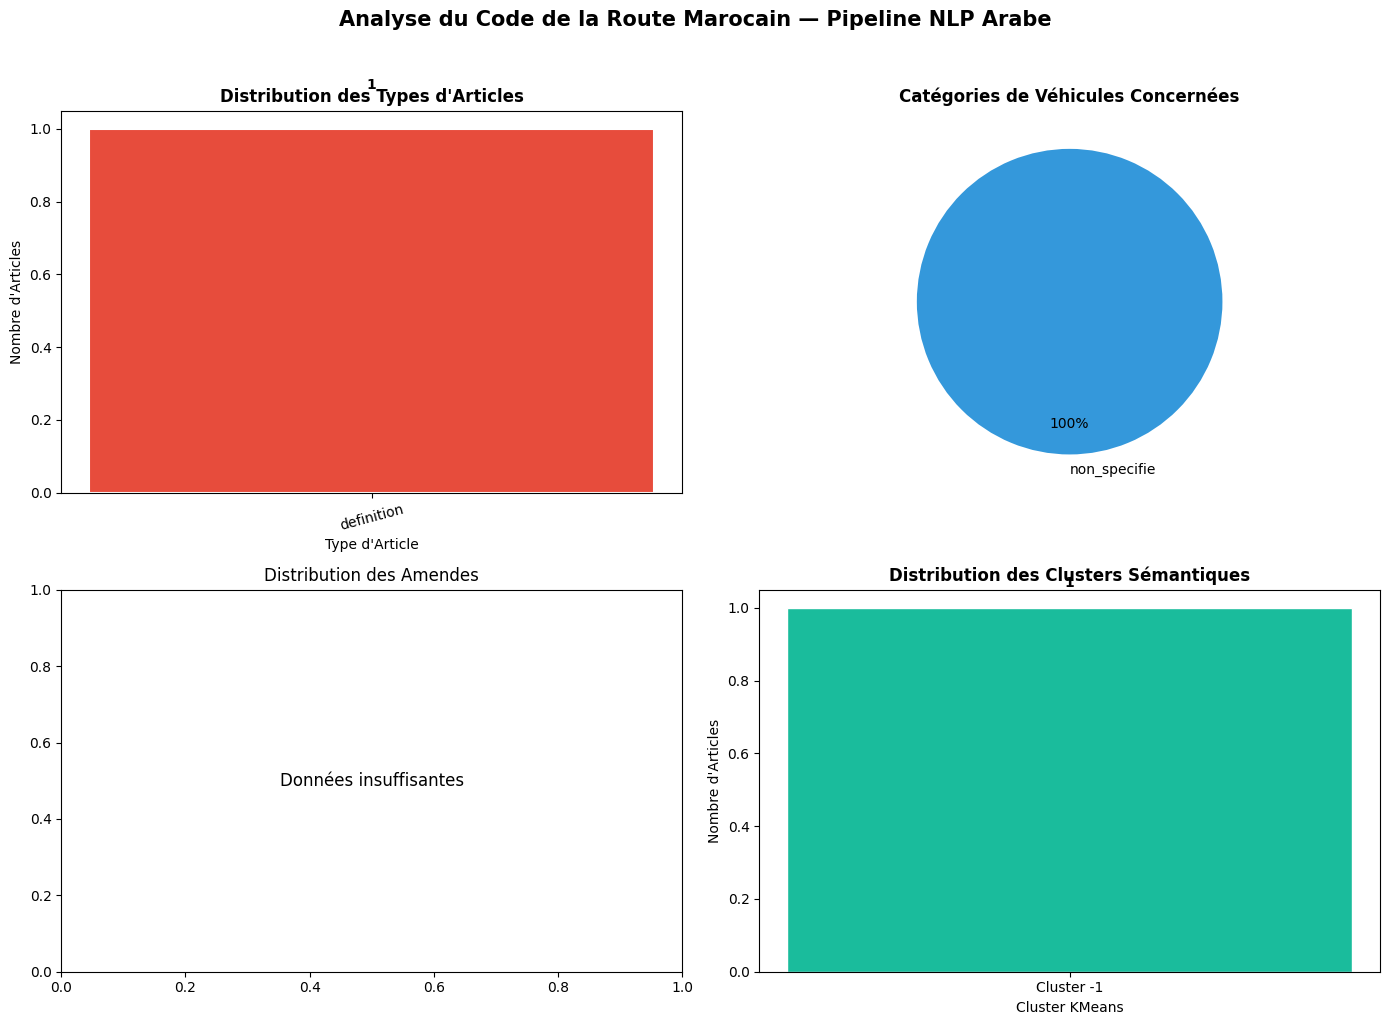

✅ Visualisations enregistrées dans 'visualisation_pipeline.png'


In [15]:
# ==============================================================
# SECTION 12.1 : DISTRIBUTION DES TYPES D'ARTICLES
# ==============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analyse du Code de la Route Marocain — Pipeline NLP Arabe',
             fontsize=15, fontweight='bold', y=1.02)

# ----- Graphique 1 : Distribution des types d'articles -----
type_counts = df['type_article'].value_counts()
colors1 = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
axes[0,0].bar(type_counts.index, type_counts.values,
              color=colors1[:len(type_counts)], edgecolor='white', linewidth=1.5)
axes[0,0].set_title('Distribution des Types d\'Articles', fontweight='bold')
axes[0,0].set_xlabel('Type d\'Article')
axes[0,0].set_ylabel('Nombre d\'Articles')
axes[0,0].tick_params(axis='x', rotation=15)
for bar in axes[0,0].patches:
    axes[0,0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                   str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# ----- Graphique 2 : Distribution des catégories de véhicules -----
veh_counts = df['categorie_vehicule'].value_counts()
axes[0,1].pie(veh_counts.values, labels=veh_counts.index, autopct='%1.0f%%',
              colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'],
              startangle=90, pctdistance=0.8)
axes[0,1].set_title('Catégories de Véhicules Concernées', fontweight='bold')

# ----- Graphique 3 : Distribution des Amendes -----
amendes_plot = df['amende_fixe'].dropna()
if not amendes_plot.empty:
    axes[1,0].hist(amendes_plot, bins=min(15, len(amendes_plot)),
                   color='#e74c3c', alpha=0.8, edgecolor='white')
    axes[1,0].axvline(amendes_plot.mean(), color='navy', linestyle='--',
                      linewidth=2, label=f'Moyenne: {amendes_plot.mean():.0f} DH')
    axes[1,0].set_title('Distribution des Montants d\'Amendes', fontweight='bold')
    axes[1,0].set_xlabel('Montant (Dirhams)')
    axes[1,0].set_ylabel('Fréquence')
    axes[1,0].legend()
else:
    axes[1,0].text(0.5, 0.5, 'Données insuffisantes', ha='center', va='center',
                   transform=axes[1,0].transAxes, fontsize=12)
    axes[1,0].set_title('Distribution des Amendes')

# ----- Graphique 4 : Distribution des Clusters -----
cluster_counts = df['cluster'].value_counts().sort_index()
bars = axes[1,1].bar([f'Cluster {c}' for c in cluster_counts.index],
                     cluster_counts.values,
                     color=['#1abc9c', '#e67e22', '#9b59b6', '#3498db', '#e74c3c'][:len(cluster_counts)],
                     edgecolor='white')
axes[1,1].set_title('Distribution des Clusters Sémantiques', fontweight='bold')
axes[1,1].set_xlabel('Cluster KMeans')
axes[1,1].set_ylabel('Nombre d\'Articles')
for bar in axes[1,1].patches:
    axes[1,1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.05,
                   str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('visualisation_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisations enregistrées dans 'visualisation_pipeline.png'")

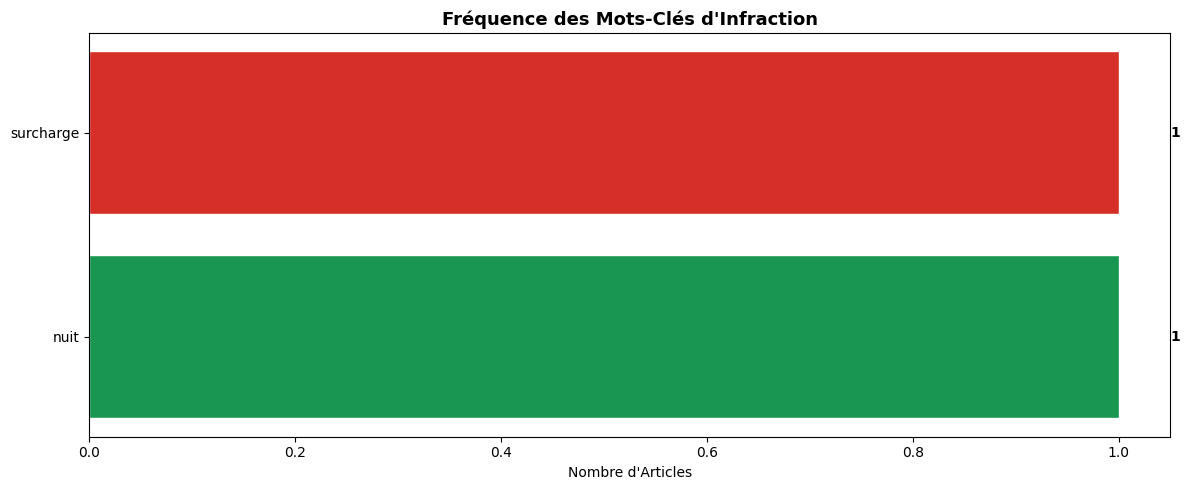

✅ Graphique mots-clés enregistré


In [16]:
# ==============================================================
# SECTION 12.2 : FRÉQUENCE DES MOTS-CLÉS D'INFRACTION
# ==============================================================

# Extraire et compter tous les mots-clés du dataset
all_keywords = []
for kw_str in df['mots_cles'].dropna():
    all_keywords.extend(kw_str.split('|'))

keyword_freq = Counter(all_keywords)
# Supprimer le tag générique 'autre'
keyword_freq.pop('autre', None)

if keyword_freq:
    fig, ax = plt.subplots(figsize=(12, 5))

    sorted_kw = sorted(keyword_freq.items(), key=lambda x: x[1], reverse=True)
    labels_kw, vals_kw = zip(*sorted_kw) if sorted_kw else ([], [])

    # Palette de couleurs dégradée
    colors_kw = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(labels_kw)))

    bars = ax.barh(labels_kw, vals_kw, color=colors_kw, edgecolor='white')
    ax.set_title('Fréquence des Mots-Clés d\'Infraction', fontweight='bold', fontsize=13)
    ax.set_xlabel('Nombre d\'Articles')

    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, vals_kw):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                str(val), ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('keywords_frequency.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Graphique mots-clés enregistré")
else:
    print("⚠️  Pas assez de mots-clés pour la visualisation")

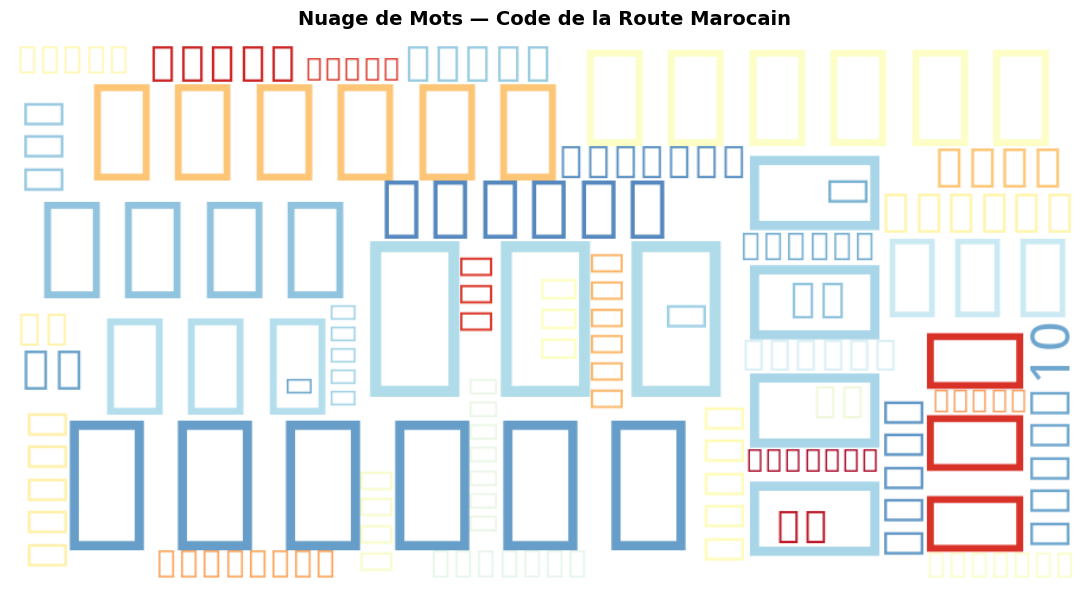

✅ Nuage de mots enregistré dans 'wordcloud_arabe.png'


In [17]:
# ==============================================================
# SECTION 12.3 : NUAGE DE MOTS ARABE
# ==============================================================

if WORDCLOUD_AVAILABLE:
    # Concaténer tous les textes d'articles
    all_texts = ' '.join(df['infraction_desc'].dropna().tolist())

    # Appliquer le reshaping arabe pour un affichage correct
    try:
        reshaped_text = arabic_reshaper.reshape(all_texts)
        bidi_text = get_display(reshaped_text)
    except:
        bidi_text = all_texts

    # Configuration du WordCloud
    wc = WordCloud(
        width=900,
        height=450,
        background_color='white',
        max_words=100,
        colormap='RdYlBu_r',
        prefer_horizontal=0.7,
        # Utiliser une police supportant l'arabe si disponible
        # font_path='/usr/share/fonts/truetype/freefont/FreeSans.ttf'
    ).generate(bidi_text)

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Nuage de Mots — Code de la Route Marocain',
                 fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('wordcloud_arabe.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Nuage de mots enregistré dans 'wordcloud_arabe.png'")
else:
    print("⚠️  WordCloud non disponible — exécutez : pip install wordcloud arabic-reshaper python-bidi")

---
#  RÉSUMÉ DU PIPELINE — Bilan Final

##  Ce que ce pipeline accomplit

```
PDF Arabe (Code de la Route)
        │
        ▼
┌──────────────────────────────────────────────────────┐
│  SECTION 4 : Extraction PDF (pdfplumber/PyMuPDF)     │
│  → Texte brut arabe extrait, page par page           │
└──────────────────────────┬───────────────────────────┘
                           │
                           ▼
┌──────────────────────────────────────────────────────┐
│  SECTION 5 : Normalisation PyArabic                  │
│  → Tashkeel, Hamza, Ta Marbuta, Tatweel supprimés    │
└──────────────────────────┬───────────────────────────┘
                           │
                           ▼
┌──────────────────────────────────────────────────────┐
│  SECTION 6 : Segmentation (الماده \d+)               │
│  → Articles individuels isolés                       │
└──────────────────────────┬───────────────────────────┘
                           │
              ┌────────────┴─────────────┐
              ▼                          ▼
┌──────────────────────┐    ┌────────────────────────────┐
│  SECTION 7 :         │    │  SECTION 8 :               │
│  Extraction Regex    │    │  Classification Hybride    │
│  amende, points,     │    │  Rules + TF-IDF + AraBERT  │
│  véhicules, durée    │    │  sanction/obligation/def   │
└──────────────────────┘    └────────────────────────────┘
              │                          │
              └────────────┬─────────────┘
                           │
                           ▼
┌──────────────────────────────────────────────────────┐
│  SECTION 9 : TF-IDF + KMeans Clustering              │
│  → Groupes sémantiques (vitesse, alcool, parking...) │
└──────────────────────────┬───────────────────────────┘
                           │
                           ▼
┌──────────────────────────────────────────────────────┐
│  SECTION 10-11 : DataFrame + export_final.csv        │
│  13 colonnes structurées, encodage UTF-8 BOM         │
└──────────────────────────────────────────────────────┘
```

## 📊 Colonnes du fichier export_final.csv

| Colonne | Description | Méthode |
|---|---|---|
| `article_id` | Numéro de l'article | Regex `الماده \d+` |
| `infraction_desc` | Description nettoyée | Segmentation + Normalisation |
| `categorie_vehicule` | Poids lourd / léger / moto / bus | Dictionnaire mots-clés |
| `amende_fixe` | Montant en DH | Regex `\d+ درهم` |
| `points_retrait` | Points perdus | Regex `خصم \d+ نقط` |
| `mots_cles` | Tags d'infraction | Dictionnaire thématique |
| `type_article` | sanction/obligation/définition | Classification hybride |
| `duree_suspension` | Durée suspension permis | Regex `لمدة \d+ سنة` |
| `cluster` | Groupe sémantique | KMeans TF-IDF |
| `gravite` | légère/modérée/grave/très grave | Règles amende + points |
| `sanction_penale` | Prison mentionnée | Regex `سجن\|حبس` |
| `en_cas_recidive` | Récidive mentionnée | Regex `تكرار` |
| `texte_complet` | Extrait original | Brut |
